SUPERSTORE EDA

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [29]:
file_path = r"E:\EME Academy classes\Python\Superstore_files\New Superstore Data (1).xlsx"
orders = pd.read_excel(file_path, sheet_name='Orders')
people = pd.read_excel(file_path, sheet_name='People')
returns = pd.read_excel(file_path, sheet_name='Returns')

In [30]:
print(f"Orders shape: {orders.shape}")
print(f"People shape: {people.shape}")
print(f"Returns shape: {returns.shape}")

Orders shape: (9994, 21)
People shape: (4, 2)
Returns shape: (800, 2)


In [31]:
# 2. Data Merging (Joining the tabs together)
# Join People to Orders based on the 'Region' column
# This adds the regional manager's name to every order
merged_data = pd.merge(orders, people, on='Region', how='left')

# Join Returns to Orders based on 'Order ID'
# Using a left join so we keep all orders, but returned ones will have 'Returned' = 'Yes'
merged_data = pd.merge(merged_data, returns, on='Order ID', how='left')

In [32]:
merged_data.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Regional Manager,Returned
0,1,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,NaN,NaN
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,NaN,NaN
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,NaN,NaN
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,NaN,NaN
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,NaN,NaN


In [33]:
merged_data.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,12420.000000,12420,12420,12409.000000,12420.000000,12420.000000,12420.000000,12420.000000
mean,4983.194767,2020-05-12 20:36:45.217391616,2020-05-16 18:32:06.956521728,57417.516480,233.629369,3.785024,0.154403,28.995935
min,1.000000,2018-01-03 00:00:00,2018-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2465.750000,2019-05-28 00:00:00,2019-06-01 00:00:00,24153.000000,17.904000,2.000000,0.000000,1.969800
50%,5095.000000,2020-07-18 00:00:00,2020-07-23 12:00:00,60623.000000,55.392000,3.000000,0.150000,9.072000
75%,7419.250000,2021-06-08 00:00:00,2021-06-10 00:00:00,90045.000000,212.680000,5.000000,0.200000,29.372000
max,9994.000000,2021-12-30 00:00:00,2022-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2888.299746,NaN,NaN,32749.815711,620.762848,2.231328,0.206124,246.506696


In [34]:
merged_data.isnull().sum()

Row ID                 0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country/Region         0
City                   0
State                  0
Postal Code           11
Region                 0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Sales                  0
Quantity               0
Discount               0
Profit                 0
Regional Manager      10
Returned            9194
dtype: int64

In [35]:
import numpy as np
# ---------------------------------------------------
# 1. LOAD THE DATA
# ---------------------------------------------------
# Replace this with the exact path and name of your raw file 
# (e.g., "store_1.csv" or the original raw joined data)
file_path = r"E:\EME Academy classes\Python\Superstore_files\store_1.csv"

# Tell Python to read the file and store it in a variable called 'df'
df = pd.read_csv(file_path, encoding='latin1')
# ---------------------------------------------------
# 2. DATA CLEANING & IMPUTATION
# ---------------------------------------------------
# PRE-CLEANING: The "Hidden Space" Fix
df['Returned'] = df['Returned'].replace(r'^\s*$', np.nan, regex=True)
df['Region'] = df['Region'].astype(str).str.strip()

# A. Relational Imputation: Fix the Region based on the State
df.loc[df['State'] == 'Kentucky', 'Region'] = 'East'
df.loc[df['State'] == 'Florida', 'Region'] = 'South'
df.loc[df['State'] == 'California', 'Region'] = 'West'

# B. Relational Imputation: Map the Regional Manager
manager_mapping = {
    'West': 'Sadie Pawthorne',
    'East': 'Chuck Magee',
    'South': 'Fred Suzuki',
    'Central': 'Roxanne Rodriguez',
    'SouthWest': 'Sadie Pawthorne' 
}
df['Regional Manager'] = df['Regional Manager'].fillna(df['Region'].map(manager_mapping))

# C. Deductive Imputation: Fill the Returned status
df['Returned'] = df['Returned'].fillna('No')

# D. Geospatial Imputation: Fill missing Postal Codes
is_burlington = (df['City'] == 'Burlington') & (df['State'] == 'Vermont')
df.loc[is_burlington, 'Postal Code'] = df.loc[is_burlington, 'Postal Code'].fillna(5401.0)

print("\n--- FINAL NULL COUNT CHECK ---")
print(df[['Region', 'Regional Manager', 'Returned', 'Postal Code']].isnull().sum())


--- FINAL NULL COUNT CHECK ---
Region              0
Regional Manager    0
Returned            0
Postal Code         0
dtype: int64


C:\Users\tatha\AppData\Local\Temp\ipykernel_19820\3294361541.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = df.set_index('Order Date').resample('M')[['Sales', 'Profit']].sum()
C:\Users\tatha\AppData\Local\Temp\ipykernel_19820\3294361541.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sub, x='Sales', y='Sub-Category', ax=axes[1, 1], palette='viridis')
C:\Users\tatha\AppData\Local\Temp\ipykernel_19820\3294361541.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mgr_perf, x='Profit', y='Regional Manager', ax=axes[2, 0], palette='coolwarm')


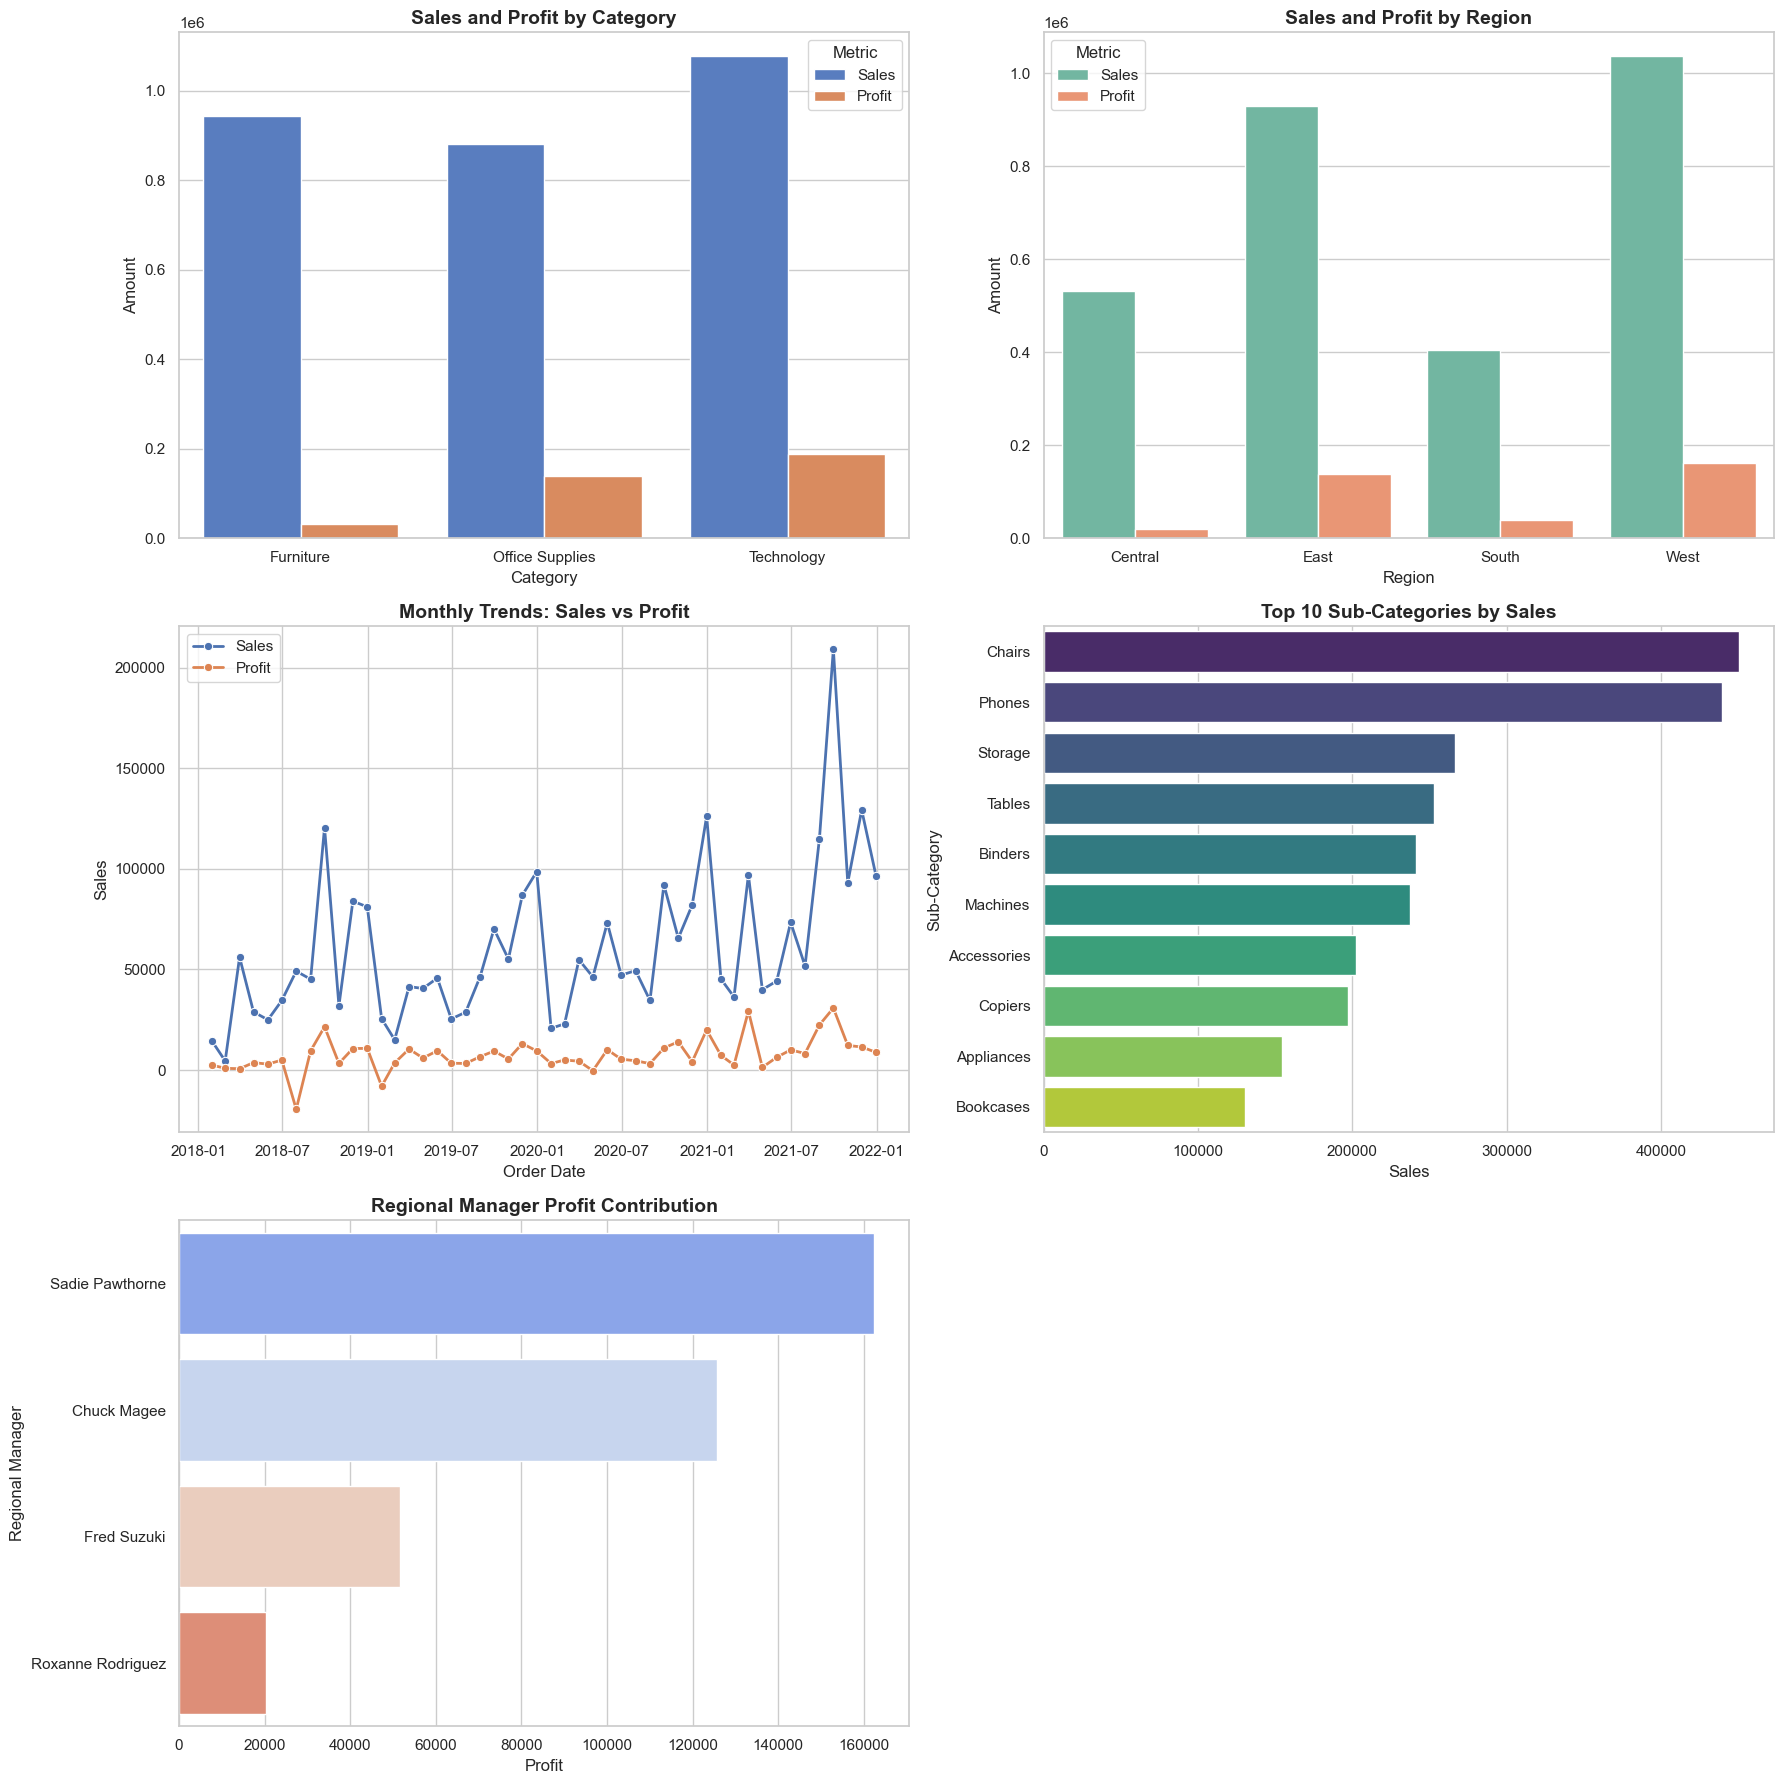

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure dates are in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Visualizations Setup
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# 1. Performance by Category
cat_perf = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
cat_melted = pd.melt(cat_perf, id_vars='Category', var_name='Metric', value_name='Amount')
sns.barplot(data=cat_melted, x='Category', y='Amount', hue='Metric', ax=axes[0, 0], palette='muted')
axes[0, 0].set_title('Sales and Profit by Category', fontweight='bold', fontsize=14)

# 2. Performance by Region
reg_perf = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
reg_melted = pd.melt(reg_perf, id_vars='Region', var_name='Metric', value_name='Amount')
sns.barplot(data=reg_melted, x='Region', y='Amount', hue='Metric', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Sales and Profit by Region', fontweight='bold', fontsize=14)

# 3. Monthly Trends: Sales vs Profit
monthly_trend = df.set_index('Order Date').resample('M')[['Sales', 'Profit']].sum()
sns.lineplot(data=monthly_trend, x=monthly_trend.index, y='Sales', ax=axes[1, 0], label='Sales', marker='o', linewidth=2)
sns.lineplot(data=monthly_trend, x=monthly_trend.index, y='Profit', ax=axes[1, 0], label='Profit', marker='o', linewidth=2)
axes[1, 0].set_title('Monthly Trends: Sales vs Profit', fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Order Date')

# 4. Top 10 Sub-Categories by Sales
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=top_sub, x='Sales', y='Sub-Category', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Top 10 Sub-Categories by Sales', fontweight='bold', fontsize=14)

# 5. Manager Performance (Profit) - Moved to fill the 5th slot
mgr_perf = df.groupby('Regional Manager')['Profit'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=mgr_perf, x='Profit', y='Regional Manager', ax=axes[2, 0], palette='coolwarm')
axes[2, 0].set_title('Regional Manager Profit Contribution', fontweight='bold', fontsize=14)

# 6. Clean up the empty subplot (Hide the 6th axes)
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

In [37]:
# ---------------------------------------------------
# 4. EXPORT THE CLEANED DATA
# ---------------------------------------------------
export_path = r"C:\Users\tatha\Downloads\New folder"
csv_filename = "Cleaned_Superstore_Data_Final.csv"

if not os.path.exists(export_path):
    os.makedirs(export_path)
    print(f"Created new directory: {export_path}")

try:
    # Notice we are exporting 'df' now, which has all our imputations!
    df.to_csv(os.path.join(export_path, csv_filename), index=False)
    print(f"Successfully exported CLEANED CSV to: {export_path}")
except Exception as e:
    print(f"An error occurred during export: {e}")

Created new directory: C:\Users\tatha\Downloads\New folder
Successfully exported CLEANED CSV to: C:\Users\tatha\Downloads\New folder


In [ ]:
import urllib
from sqlalchemy import create_engine

# --- SQL SERVER CONNECTION DETAILS ---
# Make sure to use a raw string (r"") so Python reads the backslash correctly
server = r'TATHAGATA\SQLEXPRESS' 
database = 'PRACTICEDB'
table_name = 'Cleaned Superstore data'

# We use Windows Authentication (Trusted_Connection=yes) since it's a local SQLEXPRESS instance
driver = 'ODBC Driver 17 for SQL Server' # You can change to 'SQL Server' if driver 17 isn't installed

print("Connecting to SQL Server...")

try:
    # 1. Format the connection string safely
    params = urllib.parse.quote_plus(
        f'DRIVER={{{driver}}};'
        f'SERVER={server};'
        f'DATABASE={database};'
        f'Trusted_Connection=yes;'
    )
    
    # 2. Create the SQLAlchemy Engine
    engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")
    
    # 3. Export the DataFrame to SQL Server
    # if_exists='replace' will overwrite the table if it already exists. 
    # Change to 'append' if you want to add new rows to an existing table.
    df.to_sql(
        name=table_name, 
        con=engine, 
        if_exists='replace', 
        index=False,
        chunksize=500 # Uploads in batches to prevent memory crashes
    )
    
    print(f"Success! Data exported to table '{table_name}' in database '{database}'.")

except Exception as e:
    print(f"An error occurred during export: {e}")
    print("Hint: Make sure SSMS is running and you have the correct ODBC Driver installed.")